# Nursery experiment layout TBR analysis

In [29]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from openmc_model_vault import nursery_model
import json

### Geometry

In [ ]:
model = nursery_model(1, -5.635) # Create nursery geometry for visualisation with the source at position 1.
geometry = model.geometry

Building BABY 1 geometry...
Building BABY 2 geometry...
Building BABY 3 geometry...
isotopes ['Ag107', 'Ag109', 'Al27', 'Ar36', 'Ar38', 'Ar40', 'As75', 'B10', 'B11', 'Be9', 'Bi209', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Cd106', 'Cd108', 'Cd110', 'Cd111', 'Cd112', 'Cd113', 'Cd114', 'Cd116', 'Cl35', 'Cl37', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'F19', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Sb121', 'Sb123', 'Si28', 'Si29', 'Si30', 'Sn112', 'Sn114', 'Sn115', 'Sn116', 'Sn117', 'Sn118', 'Sn119', 'Sn120', 'Sn122', 'Sn124', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'Tl203', 'Tl205', 'W182', 'W183', 'W184', 'W186', 'Zn64', 'Zn66', 'Zn67', 'Zn68', 'Zn70',

### Vault Geometry

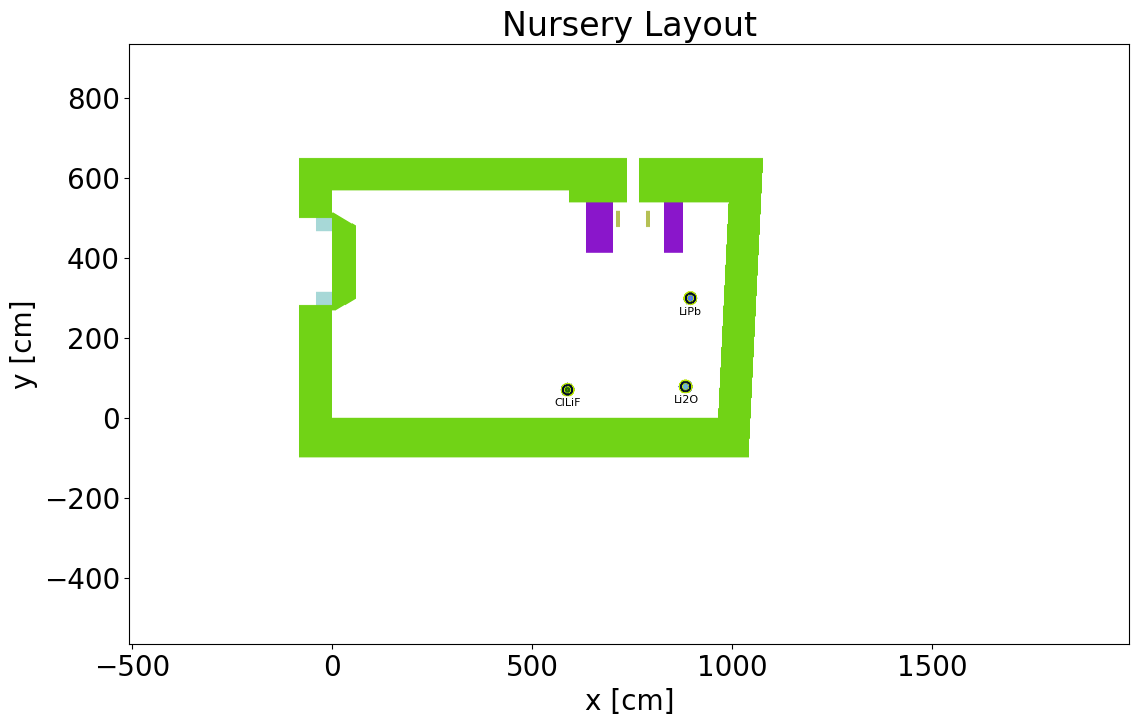

In [31]:
# Visualization

from libra_toolbox.neutronics.vault import Air
from openmc_model_vault import air, baby_positions, breeders

# Calculate midpoint position (center of bounding box)
min_xyz = np.min(baby_positions, axis=0)
max_xyz = np.max(baby_positions, axis=0)
midpoint = (min_xyz + max_xyz) / 2
x_c, y_c, z_c = midpoint

ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)

# Add breeder material labels under each BABY
for (bx, by, bz), breeder in zip(baby_positions, breeders):
    ax.text(
        bx, by - 20,  # Adjust -20 as needed for spacing
        breeder,
        color='black',
        fontsize=8,
        ha='center',
        va='top',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )

ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout", fontsize=24)
plt.show()

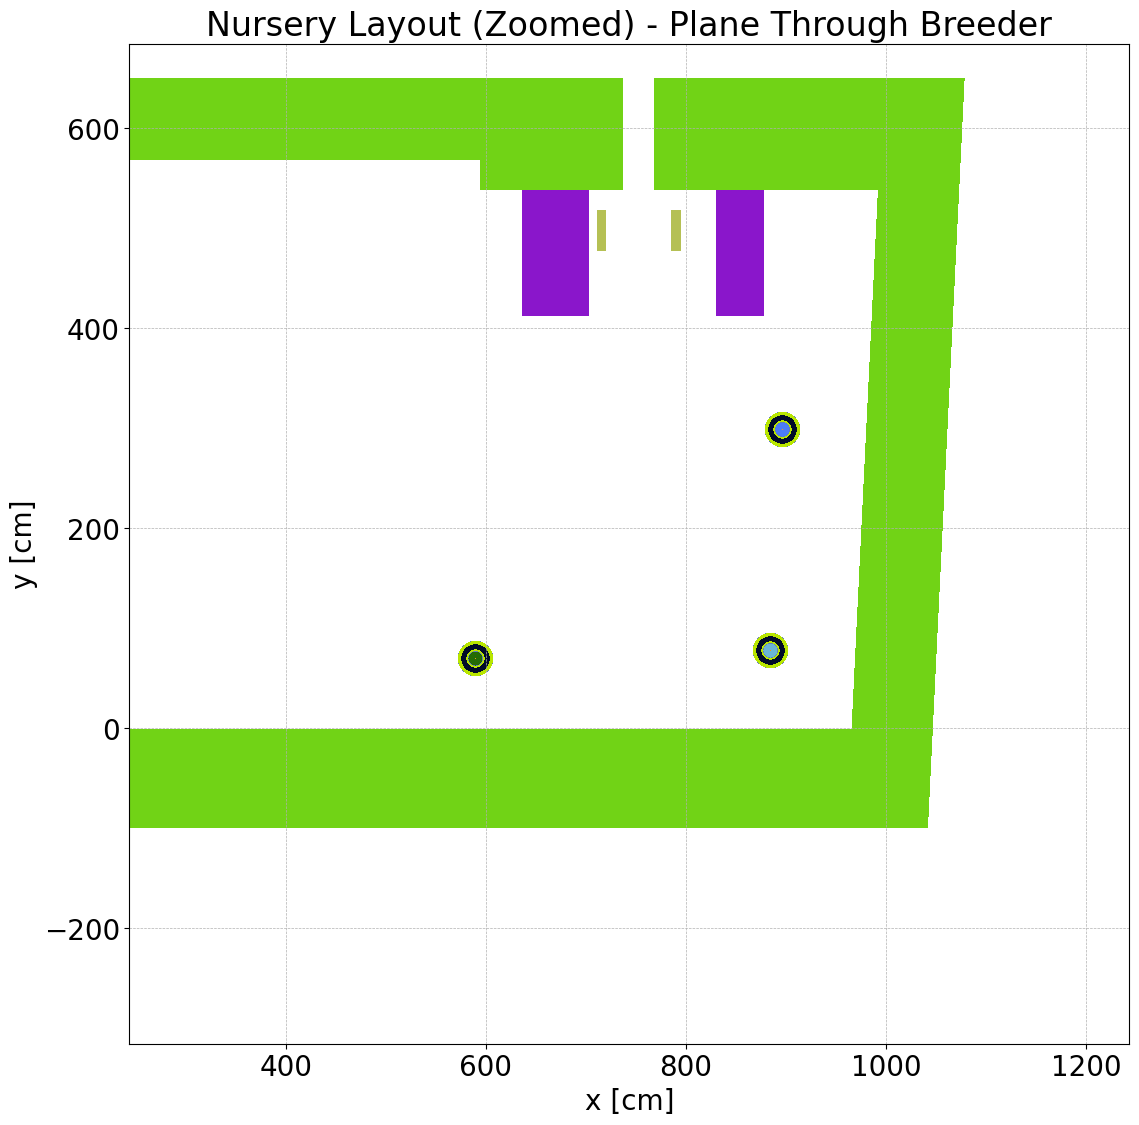

In [32]:
ax = geometry.plot(
    width=(1000, 1000),
    origin=(x_c, y_c, z_c + 10), # z_c + 10 to cut through the breeder plane
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout (Zoomed) - Plane Through Breeder", fontsize=24)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

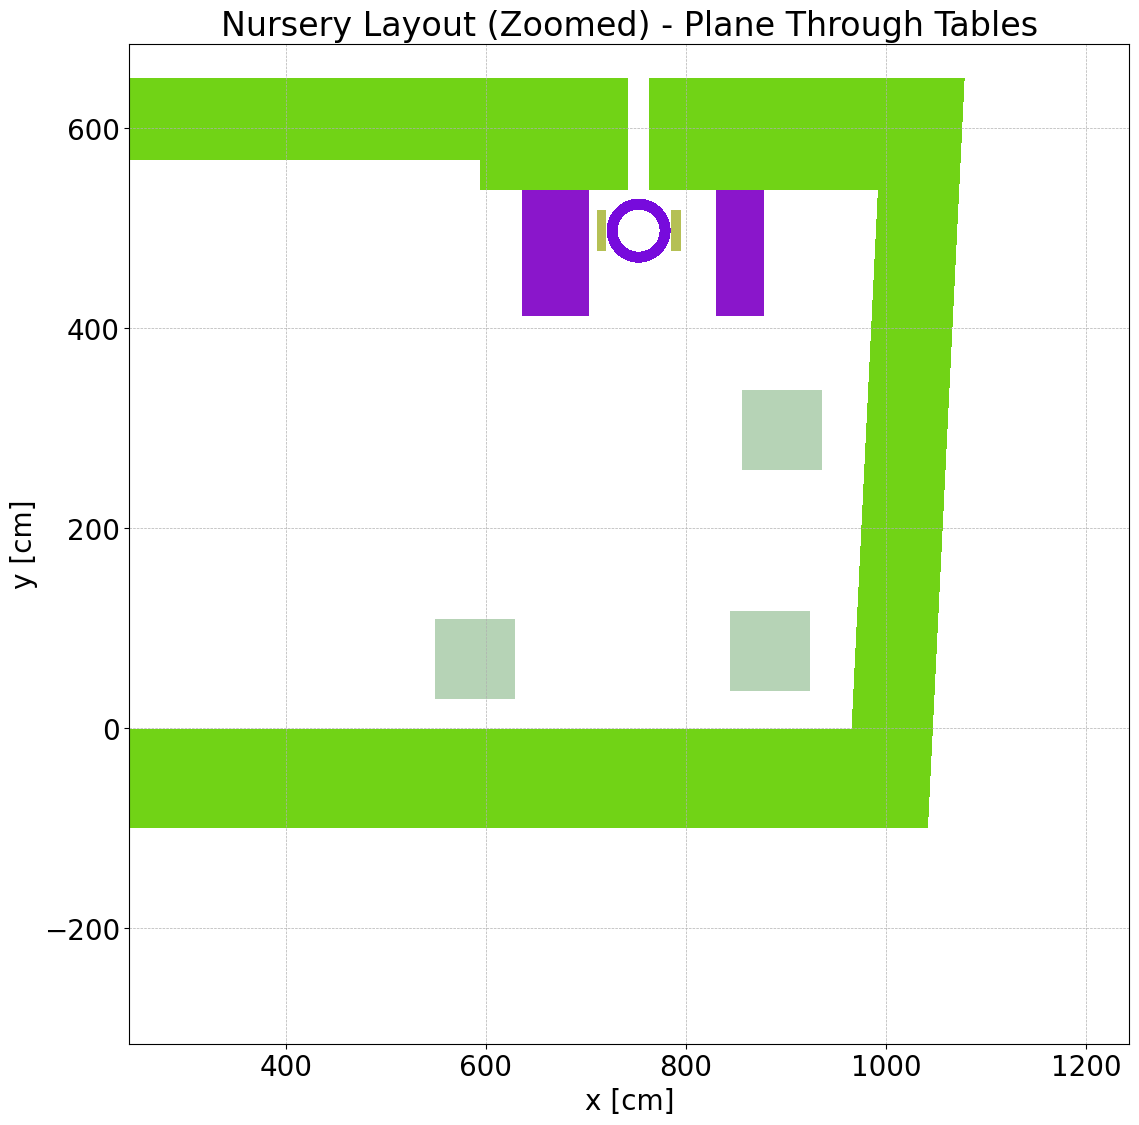

In [33]:
ax = geometry.plot(
    width=(1000, 1000),
    origin=(x_c, y_c, z_c + 1), # z_c + 1 to cut through the table plane
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
ax.set_title("Nursery Layout (Zoomed) - Plane Through Tables", fontsize=24)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

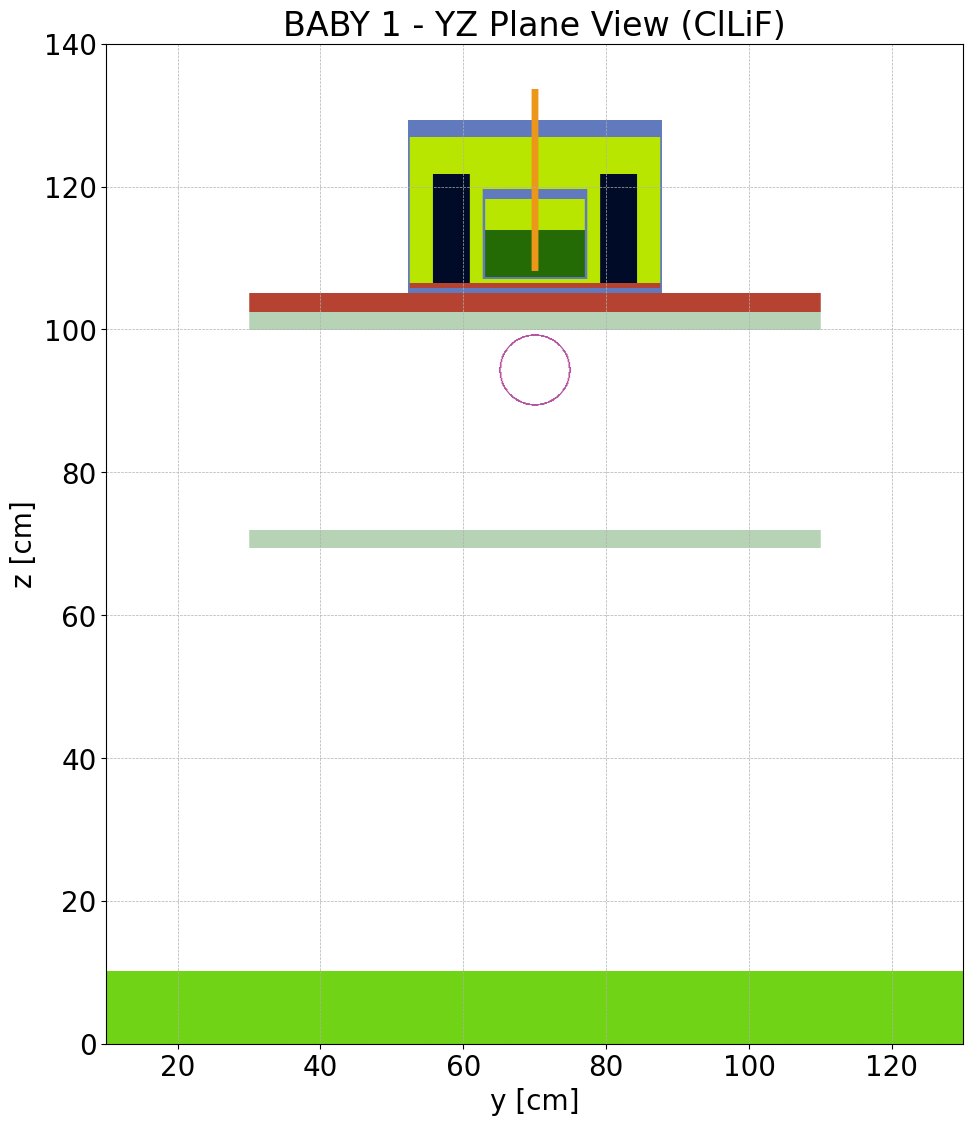

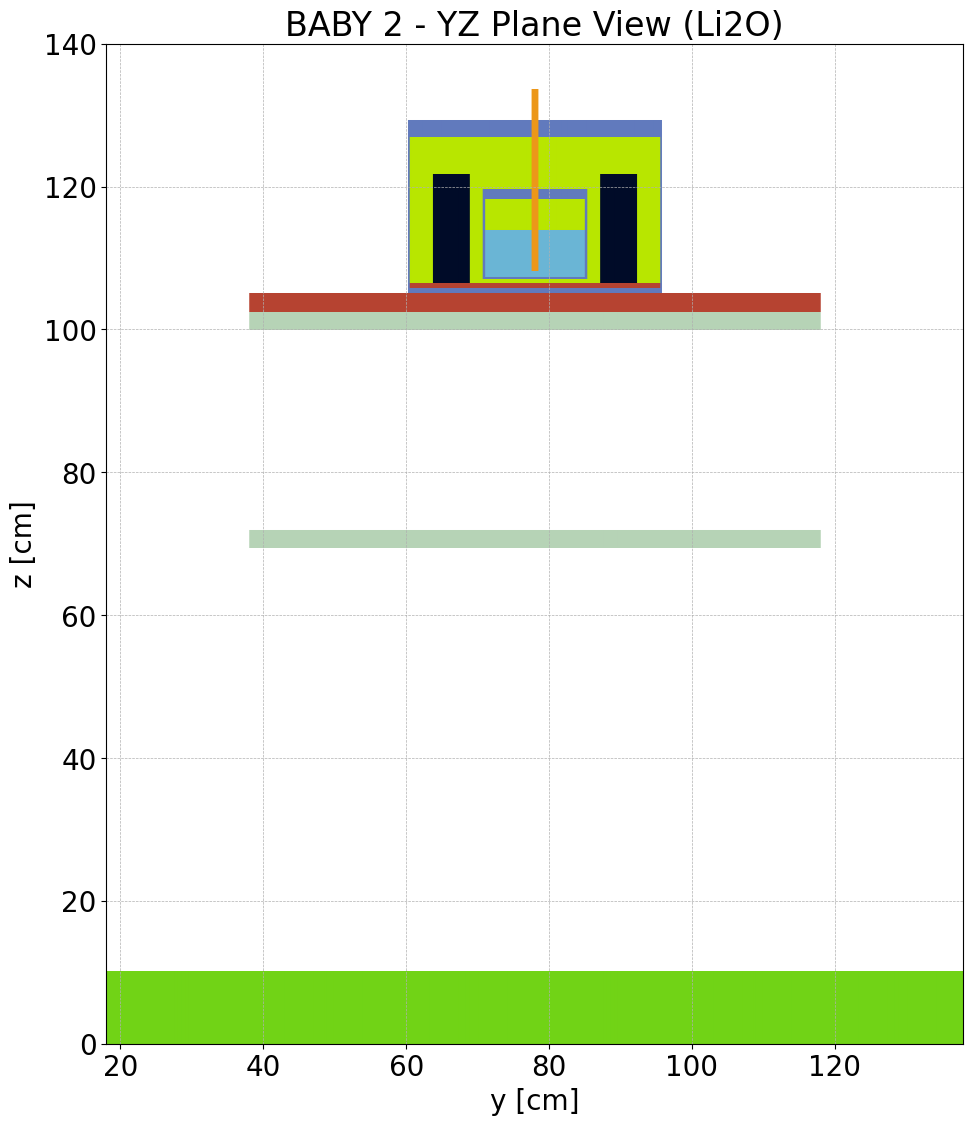

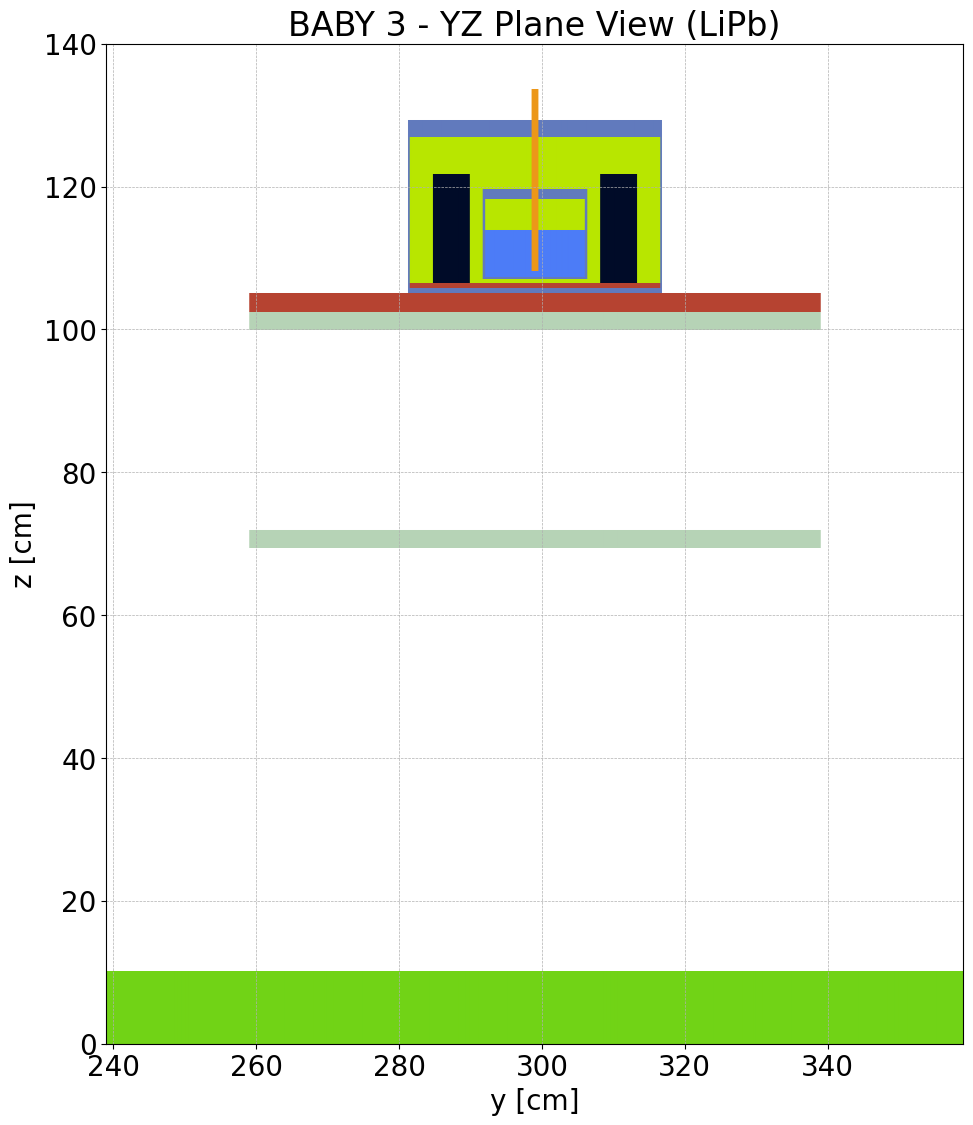

In [34]:
for i, (x_c, y_c, z_c) in enumerate(baby_positions):
    ax = geometry.plot(
        width=(120, (z_c + 40)),
        origin=(x_c, y_c, (z_c + 40)/2),
        pixels=(1000, 1000),
        basis="yz",
        color_by="material",
        colors={Air: "white", air: "white"},
    )
    ax.tick_params(axis="both", labelsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=20)
    ax.set_ylabel(ax.get_ylabel(), fontsize=20)
    ax.set_title(f"BABY {i+1} - YZ Plane View ({breeders[i]})", fontsize=24)
    plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
    plt.show()

### Display TBR results

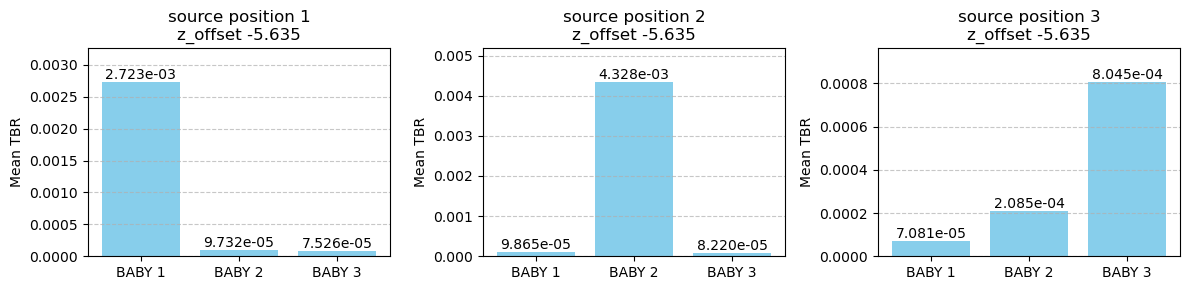

In [42]:
# Load the processed data
processed_data_file = "../../data/processed_data.json"
with open(processed_data_file, "r") as f:
    results = json.load(f)

# Get sorted source positions
# Keys are like "source position 1" so sort by the numeric part
def get_sp_val(key):
    try:
        return float(key.split()[-1])
    except Exception:
        return 0

source_positions = sorted(results.keys(), key=get_sp_val)

# Collect all unique z_offsets from all source positions
z_offsets_set = set()
for sp_key in results:
    for z_key in results[sp_key].keys():
        z_offsets_set.add(z_key)
        
# Keys are like "z_offset -5.635"; sort them by the numeric value
def get_z_val(zkey):
    try:
        return float(zkey.split()[1])
    except Exception:
        return 0

z_offsets = sorted(list(z_offsets_set), key=get_z_val)

# Create subplots grid: rows for z_offsets (y-direction) and columns for source positions (x-direction)
nrows = len(z_offsets)
ncols = len(source_positions)
fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

# Loop over the grid and plot the bar charts
for col, sp_key in enumerate(source_positions):
    for row, z_key in enumerate(z_offsets):
        ax = axs[row, col]
        run_data = results[sp_key].get(z_key, {})  # get the results for this combination
        if not run_data:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(f"{sp_key}, {z_key}")
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        # Assume the keys in run_data are like "modelled_TBR_1", "modelled_TBR_2", etc.
        baby_keys = sorted(run_data.keys(), key=lambda x: int(x.split('_')[-1]))
        tbr_means = [run_data[bk]["mean"] for bk in baby_keys]
        labels = [f"BABY {i+1}" for i in range(len(tbr_means))]

        bars = ax.bar(labels, tbr_means, color='skyblue')
        ax.set_ylim(0, max(tbr_means)*1.2)
        ax.set_title(f"{sp_key}\n{z_key}")
        ax.set_ylabel("Mean TBR")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Add annotations: print the TBR mean above each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height, 
                f"{height:.3e}",
                ha='center', 
                va='bottom'
            )

plt.tight_layout()
plt.show()

### Results print out

In [41]:
# --- Print out TBR results after the plot ---
print("\nTBR Results Summary:")
for sp_key in source_positions:
    print(f"\nSource Position: {sp_key}")
    for z_key in sorted(results[sp_key].keys(), key=get_z_val):
        print(f"  {z_key}:")
        run_data = results[sp_key][z_key]
        # Sorting the baby keys for consistency
        baby_keys = sorted(run_data.keys(), key=lambda x: int(x.split('_')[-1]))
        for bk in baby_keys:
            mean = run_data[bk]["mean"]
            std_dev = run_data[bk]["std_dev"]
            rel_std_dev = run_data[bk].get("relative_std_dev", std_dev/mean if mean != 0 else 0)
            print(f"    {bk}: Mean = {mean:.6e}, Std Dev = {std_dev:.6e}, Relative Std Dev = {rel_std_dev:.6e}")

print("end")


TBR Results Summary:

Source Position: source position 1
  z_offset -5.635:
    modelled_TBR_1: Mean = 2.722699e-03, Std Dev = 4.634416e-05, Relative Std Dev = 1.702141e-02
    modelled_TBR_2: Mean = 9.731668e-05, Std Dev = 1.548334e-05, Relative Std Dev = 1.591026e-01
    modelled_TBR_3: Mean = 7.526078e-05, Std Dev = 1.506435e-05, Relative Std Dev = 2.001620e-01

Source Position: source position 2
  z_offset -5.635:
    modelled_TBR_1: Mean = 9.864701e-05, Std Dev = 1.610629e-05, Relative Std Dev = 1.632720e-01
    modelled_TBR_2: Mean = 4.327884e-03, Std Dev = 6.472859e-05, Relative Std Dev = 1.495618e-02
    modelled_TBR_3: Mean = 8.219729e-05, Std Dev = 1.494629e-05, Relative Std Dev = 1.818344e-01

Source Position: source position 3
  z_offset -5.635:
    modelled_TBR_1: Mean = 7.081303e-05, Std Dev = 1.284903e-05, Relative Std Dev = 1.814501e-01
    modelled_TBR_2: Mean = 2.085307e-04, Std Dev = 2.656930e-05, Relative Std Dev = 1.274119e-01
    modelled_TBR_3: Mean = 8.044860e-